In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('e-com.csv', encoding='ISO-8859-1')
data.shape

(3312, 19)

In [ ]:
data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

In [ ]:
#Part I - NumPy

In [ ]:
#Task 1
quantity = np.asarray(data['Quantity'])
quantity = quantity[:144].reshape((12,12))
mean, median = np.round(np.mean(quantity)), np.median(quantity)
print("Original matrix: \n")
print(quantity, '\n')
#1.1
np.fill_diagonal(quantity, mean) #thanks, NumPy
print("Main diagonal replaced: \n")
print(quantity.diagonal(), '\n')
#1.2
np.fill_diagonal(np.fliplr(quantity), median) #left-right flip
print("Secondary diagonal replaced: \n")
print(np.fliplr(quantity).diagonal(), '\n')
#1.3
inset_matrix = quantity[1:-1, 1:-1].copy()
quantity *= 2
quantity[1:-1, 1:-1] = inset_matrix
print("Border elements are multiplied: \n")
print(quantity, '\n')
#1.4
quantity[1:-1, 1:-1] = np.zeros_like(inset_matrix)
print("Here is the sum of all the border elements: \n")
print(np.sum(quantity), '\n')
quantity[1:-1, 1:-1] = inset_matrix #should be put back
quantity_for_plot = quantity.copy()

Original matrix: 

[[ 4 11  2  5  5  4  4  5 14  2  2  5]
 [ 6  2  2  5  3  1  6  8  3  7  2  3]
 [11  3  7  1  2  3  6  2  1  5  5  6]
 [ 5  3  1  5  7  9  3  7  2  5  2  5]
 [ 5  2  4  2  4  1  4  2  1  8  2  5]
 [ 4  2  8  1  4  7  4  3  7  2  2  2]
 [ 3  4  4  1  3  1  3  3  5  3  2  5]
 [ 3  3  6  4  1  5  7  7  5  5  4  3]
 [ 1  4  5  3  2  3  5  3  2  5  4  1]
 [ 6  2  2  3  3  2  3  7  2  2  8  4]
 [ 7  3  3  3  3  3  3  5  9  4  3  1]
 [ 8  2  2  2  5  1  3  2  3  5  1  2]] 

Main diagonal replaced: 

[4 4 4 4 4 4 4 4 4 4 4 4] 

Secondary diagonal replaced: 

[3 3 3 3 3 3 3 3 3 3 3 3] 

Border elements are multiplied: 

[[ 8 22  4 10 10  8  8 10 28  4  4  6]
 [12  4  2  5  3  1  6  8  3  7  3  6]
 [22  3  4  1  2  3  6  2  1  3  5 12]
 [10  3  1  4  7  9  3  7  3  5  2 10]
 [10  2  4  2  4  1  4  3  1  8  2 10]
 [ 8  2  8  1  4  4  3  3  7  2  2  4]
 [ 6  4  4  1  3  3  4  3  5  3  2 10]
 [ 6  3  6  4  3  5  7  4  5  5  4  6]
 [ 2  4  5  3  2  3  5  3  4  5  4  2]
 [12  2  3  

In [ ]:
#Task 2
arr = [1,2,3,2,1,3,2,1]
def detect_streaks(arr, n):
  arr = np.asarray(arr)
  increasing, decreasing = np.diff(arr) > 0, np.diff(arr) < 0
  def starts(monotonicity):
    padded = np.concatenate([[False], monotonicity, [False]])
    edges = np.diff(padded.astype(int))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    lengths = ends - starts
    return starts[lengths >= n - 1]
  return starts(increasing), starts(decreasing)
inc, dec = detect_streaks(arr, 3)
print(inc, dec)

[0] [2 5]


In [ ]:
#Let's test it
sales = np.asarray(data['Sales'])
inc, dec = detect_streaks(sales, 5)
print(inc, dec)

[  58  121  628  665  814  824 1253 1369 1528 1876 2454 2546 2559 2640
 2748 2798 2817 3202] [  28  175  258  376  582  727  844  952 1109 1268 1311 1504 1518 1628
 1675 1872 2089 2384 2392 2499 2534 2597 2673 2922 2934 3173 3240]


In [ ]:
#Task 3
quantity = np.asarray(data['Quantity'])
mean_quantity = np.mean(quantity)
mask = ((quantity % 5 == 0) & (quantity > mean_quantity)) #e.g. pallettes of 5

print(f"The number of True's: {mask.sum()}\n")
filtered_indices = np.where(mask)[0]
for i in range(6):
  filtered_index = filtered_indices[i]
  print(f"At an index {filtered_index} - the value {quantity[filtered_index]} is located")

The number of True's: 456

At an index 3 - the value 10 is located
At an index 4 - the value 10 is located
At an index 7 - the value 10 is located
At an index 15 - the value 5 is located
At an index 34 - the value 5 is located
At an index 36 - the value 10 is located


In [ ]:
#Part II - Pandas
# Task 1
# 1.1
queried_ten = data.query('(Profit <= (Sales * 0.1))') #E.g. We have not earned more than 10% on these sales
print(queried_ten)

     Order Date  Row ID        Order ID       Ship Mode Customer ID   Segment  \
3      01-01-20    8070  CA-2017-151750  Standard Class    JM-15250  Consumer   
4      01-01-20    8071  CA-2017-151750  Standard Class    JM-15250  Consumer   
5      01-01-20    8072  CA-2017-151750  Standard Class    JM-15250  Consumer   
7      01-01-20    8074  CA-2017-151750  Standard Class    JM-15250  Consumer   
8      01-01-20    8075  CA-2017-151750  Standard Class    JM-15250  Consumer   
...         ...     ...             ...             ...         ...       ...   
3293   29-12-20    1878  CA-2017-118885  Standard Class    JG-15160  Consumer   
3294   29-12-20    1879  CA-2017-118885  Standard Class    JG-15160  Consumer   
3306   30-12-20     907  CA-2017-143259  Standard Class    PO-18865  Consumer   
3307   30-12-20     908  CA-2017-143259  Standard Class    PO-18865  Consumer   
3311   30-12-20    5092  CA-2017-156720  Standard Class    JM-15580  Consumer   

            Country        

In [ ]:
#1.2
mask = (data['Sales'] > data['Sales'].shift(1)) & (data['Sales'] < data['Sales'].shift(-1))
print(data[mask])

     Order Date  Row ID        Order ID       Ship Mode Customer ID  \
8      01-01-20    8075  CA-2017-151750  Standard Class    JM-15250   
9      01-01-20    8076  CA-2017-151750  Standard Class    JM-15250   
12     02-01-20    1343  CA-2017-113481     First Class    AS-10045   
18     03-01-20    5258  US-2017-114034  Standard Class    DL-13315   
21     06-01-20    4937  CA-2017-150931  Standard Class    DP-13390   
...         ...     ...             ...             ...         ...   
3279   28-12-20     954  CA-2017-136539  Standard Class    GH-14665   
3286   28-12-20    6820  CA-2017-163860  Standard Class    LO-17170   
3290   28-12-20    7486  CA-2017-135111  Standard Class    CS-12400   
3299   29-12-20    5458  CA-2017-130631  Standard Class    BS-11755   
3302   29-12-20    7635  US-2017-158526    Second Class    KH-16360   

          Segment        Country              City           State  \
8        Consumer  United States        Huntsville           Texas   
9      

In [ ]:
#1.3
data['Difference'] = data['Sales'].sub(data['Profit'], axis=0).abs()
print(data.groupby('Sub-Category')['Difference'].mean().nlargest(5))

Sub-Category
Copiers      1721.254445
Machines     1406.481533
Tables        663.790742
Chairs        462.688441
Bookcases     402.735603
Name: Difference, dtype: float64


In [ ]:
#Task 2
#2.1 Min-Max Normalization
data['Norm_Discount'] = (data['Discount'] - data['Discount'].min()) /\
 (data['Discount'].max() - data['Discount'].min())

In [ ]:
#2.2
data['Difference_Ratio'] = (data['Profit'] - data['Sales'])/data['Profit']

In [ ]:
#2.3
diff_trends = data['Profit'].diff()
conditions = [diff_trends > 0, diff_trends< 0]
choices = ["Up", "Down"]
data['Trend_Label'] = np.select(conditions, choices, default="Stable")

In [ ]:
data.columns #Everybody's there

Index(['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Difference', 'Norm_Discount',
       'Difference_Ratio', 'Trend_Label'],
      dtype='object')

In [ ]:
#2* Some arbitraty score formula
trend_label_score = data['Trend_Label'].map({
    "Down" : 0.0,
    "Stable" : 0.3,
    "Up" : 0.6
})

data['Score'] = 0.1 * data['Norm_Discount'] +\
 trend_label_score + 0.3 * data['Difference_Ratio']

In [ ]:
#Task 3

import warnings
warnings.filterwarnings("ignore") #They are always yapping... Why change then?

#First approach, I have used some techniques from Time Series chapters, and put
#there some function that were mentioned in the task. Though it can be more succinct.
#In this approach I have not implemented any 'growth' columns and treated profit as such

data_for_ts = data[['Order Date', 'Profit']]
data_for_ts.rename(columns={'Order Date': 'Order_Date'}, inplace=True)
data_for_ts.sort_values('Order_Date')
data_for_ts['Order_Date'] = pd.to_datetime(data_for_ts['Order_Date'])
data_for_ts = data_for_ts.set_index(['Order_Date'])
grouped_data = data_for_ts.groupby('Order_Date')['Profit'].sum()
print(grouped_data.resample('M').max().nlargest(1))

Order_Date
2020-03-31    6818.6276
Freq: ME, Name: Profit, dtype: float64


In [ ]:
#Second approach, a bit closer to the requirement, with my own understanding of what
#that growth might be

df3 = data
df3.rename(columns={'Order Date': 'Order_Date'}, inplace=True)
df3.sort_values('Order_Date')
df3['Growth'] = df3['Profit'].diff()
df3['Order_Date'] = pd.to_datetime(df3['Order_Date'])
df3['Month'] = df3['Order_Date'].dt.to_period('M')
df3 = df3.set_index(['Month'])
monthly_growth = df3.groupby('Month')['Growth'].sum()
print(f"Best month: {monthly_growth.idxmax()}")

Best month: 2020-01


In [ ]:
 #Part III - Visualization

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

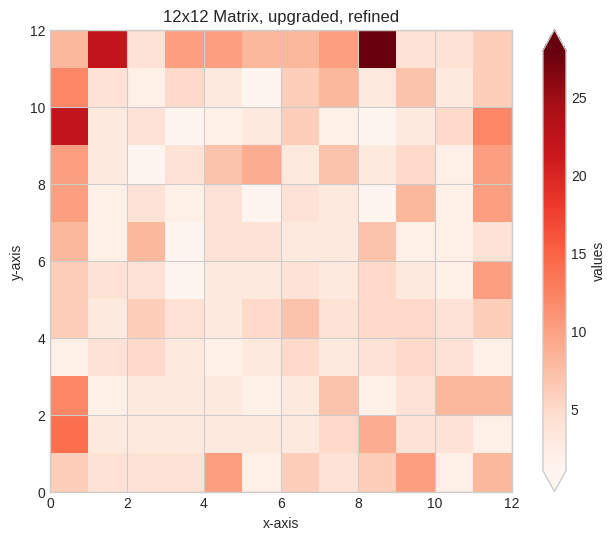

In [ ]:
#Matrix for Part I, Task 1
#This beautiful imshow visualizes our matrix with reds being extreme upper values
#Appart from our task, it depicts the relationship between the x and y axis

plt.figure(figsize=(8,6))
plt.imshow(quantity_for_plot, extent=[0, 12, 0, 12], origin='upper', cmap='Reds',\
          interpolation='auto', aspect='equal')
plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.title('12x12 Matrix, upgraded, refined')
plt.colorbar(extend='both', label='values');

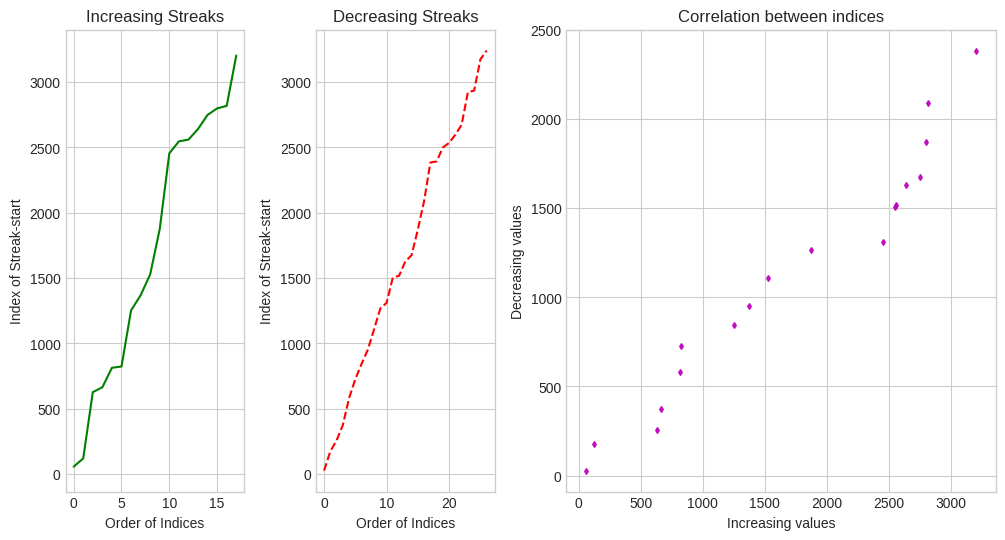

In [ ]:
#Part I, Task 2 Sales streaks
#First two plots depict emergence of corresponding streaks. When the slope is lower,
#streaks appear more frequent at a particular index of an array (depicted on the left).
#Second plot depicts an attempt to find a dependence between two streaks. Further research
#awaits...

fig = plt.figure(figsize=(12, 6))
grid = plt.GridSpec(1, 4, hspace=0.4, wspace=0.4)
left_ax = fig.add_subplot(grid[0, 0])
middle_ax = fig.add_subplot(grid[0, 1], sharey=left_ax)
right_ax = fig.add_subplot(grid[0, 2:])
left_ax.plot(inc, '-g')
left_ax.set_title('Increasing Streaks')
left_ax.set_ylabel('Index of Streak-start')
left_ax.set_xlabel('Order of Indices')
middle_ax.plot(dec, '--r')
middle_ax.set_title('Decreasing Streaks')
middle_ax.set_xlabel('Order of Indices')
middle_ax.set_ylabel('Index of Streak-start')
right_ax.plot(inc, dec[:18], 'dm', markersize=3, alpha=0.9)
plt.title('Correlation between indices')
plt.xlabel('Increasing values')
plt.ylabel('Decreasing values');

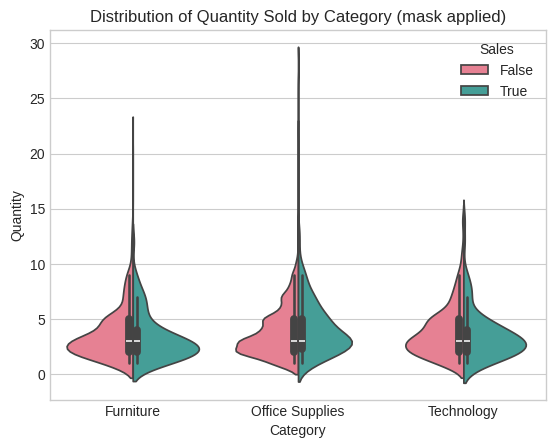

In [ ]:
#Part I, Task 3 Here we can see the result of mask implementation, I will remind you
#that the mask allowed us to choose elements which are multiples of 5 and above the array mean.
#We can conclude that, for example, goods of smaller quantites were more likely to be sold.
#Being in mutliples of 5 and above the average (provided that the average was a little less than five)
#seems to be quite a popular characteristic of quantity. We can even observe a slight spike, when
#looking at 10.
#Technology as a category is demonstrating less outliers than the remaining categories.

sns.violinplot(data=data, x=data['Category'], y=data['Quantity'], hue=mask, split=True, palette='husl')
plt.title("Distribution of Quantity Sold by Category (mask applied)")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

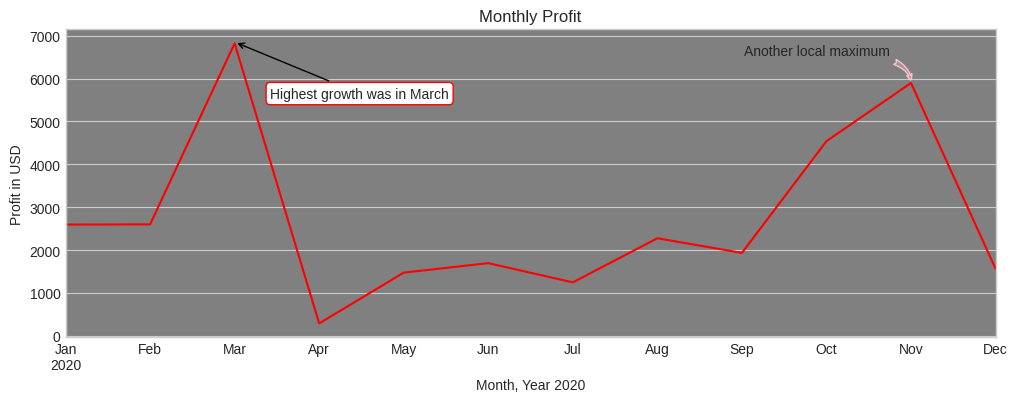

In [ ]:
#Part II, Task 3 - Highest Cummulative Growth (Profit) - in this example.
#The graph fluctuates wildly, but we can obeserve that the shop on the float, making profit.
#After March there was a sharp drop and a very slow ascent that resulted in another profit maximum,
#this time in November. That would be interesting to see the data from the other years...

monthly_profit = grouped_data.resample('M').max()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_profit.plot(ax=ax, color='red')

ax.annotate("Highest growth was in March", xy=('2020-03-1', 6850),  xycoords='data',
            bbox=dict(boxstyle="round", fc="white", ec="red"),
            xytext=(90, -40), textcoords='offset points', ha='center',
            arrowprops=dict(arrowstyle="->"))

ax.annotate('Another local maximum', xy=('2020-11-1', 5900),  xycoords='data',
            xytext=(-120, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="pink",
                            connectionstyle="angle3,angleA=0,angleB=-90"))
ax.set_facecolor('gray')
ax.set(title="Monthly Profit", xlabel="Month, Year 2020", ylabel="Profit in USD");

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
grouped_data = grouped_data.resample('M').max()
grouped_data.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 12 entries, 2020-01-31 to 2020-12-31
Freq: ME
Series name: Profit
Non-Null Count  Dtype  
--------------  -----  
12 non-null     float64
dtypes: float64(1)
memory usage: 192.0 bytes


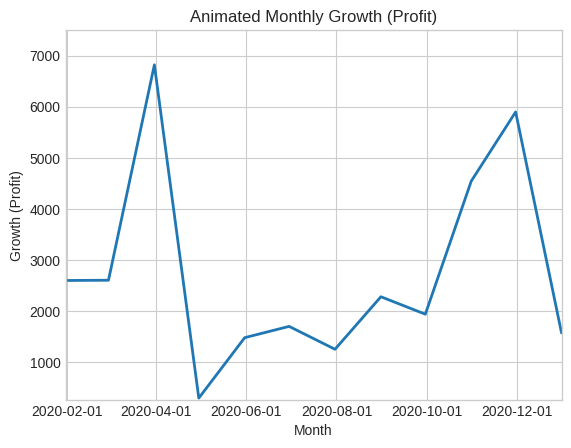

In [ ]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
line, = ax.plot([],[], lw=2)
ax.set_xlim(grouped_data.index.min(), grouped_data.index.max())
ax.set_ylim(grouped_data.min() * 0.9, grouped_data.max() * 1.1)
ax.set_title("Animated Monthly Growth (Profit)")
ax.set_xlabel("Month")
ax.set_ylabel("Growth (Profit)")
ax.set_xticks(ax.get_xticks()[::2])

def init():
    line.set_data([], [])
    return line,

def update(frame):
    x = grouped_data.index[:frame]
    y = grouped_data.values[:frame]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=len(grouped_data) + 1, init_func=init, interval=200, blit=True)
HTML(ani.to_jshtml())

In [ ]:
df_anim = monthly_growth

In [ ]:
df3 = data
df3.rename(columns={'Order Date': 'Order_Date'}, inplace=True)
df3.sort_values('Order_Date')
df3['Growth'] = df3['Profit'].diff()
df3['Month'] = pd.to_datetime(df3['Order_Date'])
df3 = df3.set_index(['Month'])
monthly_growth = df3.groupby('Month')['Growth'].sum()
monthly_growth.resample('M').mean()

,Growth
Month,
2020-01-31,41.228508
2020-02-29,-2.927357
2020-03-31,3.260552
2020-04-30,-7.345331
2020-05-31,8.994427
2020-06-30,2.368950
2020-07-31,19.886236
2020-08-31,1.156029
2020-09-30,-11.504036
